# 5.3 Análise exploratória das features — Cartola FC

Análise do dataset de modelagem (`df_features`) construído na seção 5.2.
Cada linha é um par `(atleta_id, rodada_id)` e as features da rodada `t` usam apenas informação das rodadas `1..t-1`.

O objetivo desta seção não é treinar modelos, e sim **validar a engenharia de features** e **justificar escolhas metodológicas da seção 5.4**: recorte temporal do walk-forward, regularização vs. árvores, imputação de H2H, um modelo por posição vs. modelo único, e o papel do `status_id`.


## 5.3.0 Setup, dados e contrato de colunas


In [1]:
%matplotlib inline

from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 80)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "database" / "df_features.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/database/df_features.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "database"
FIG_DIR = PROJECT_ROOT / "data" / "eda" / "features"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "df_features.csv")
games = pd.read_csv(DATA_DIR / "games.csv")

POS_MAP = {
    1: "Goleiro",
    2: "Lateral",
    3: "Zagueiro",
    4: "Meia",
    5: "Atacante",
    6: "Técnico",
}
STATUS_MAP = {
    7: "Provável",
    6: "Dúvida",
    5: "Suspenso",
    3: "Lesionado",
    2: "Não Participará",
}
STATUS_ORDER = ["Provável", "Dúvida", "Suspenso", "Lesionado", "Não Participará"]
POS_ORDER = ["Goleiro", "Lateral", "Zagueiro", "Meia", "Atacante", "Técnico"]

df["posicao"] = df["posicao_id"].map(POS_MAP)
df["status_label"] = df["status_id"].map(STATUS_MAP)

TARGET = "pontos_num"
ID_LIKE = ["atleta_id", "apelido", "posicao_id", "clube_id", "adversario_id", "posicao", "status_label"]
MODEL_FEATURES = [
    column
    for column in df.columns
    if column not in ID_LIKE and column != TARGET and pd.api.types.is_numeric_dtype(df[column])
]
CORE_FEATURES = [column for column in MODEL_FEATURES if column != "h2h_pts_avg"]
DISCRETE_FEATURES = [
    "is_mandante",
    "fase_campeonato",
    "status_id",
    "pos_goleiro",
    "pos_lateral",
    "pos_zagueiro",
    "pos_meia",
    "pos_atacante",
    "pos_tecnico",
]

AZUL = "#003366"
VERDE = "#1a7a4a"
LARANJA = "#E67E22"
CINZA = "#7F8C8D"
VERMELHO = "#C0392B"
ROXO = "#6C3483"
CIANO = "#148F77"
AMARELO = "#D4AC0D"

PALETTE_POS = {
    "Goleiro": AZUL,
    "Zagueiro": VERDE,
    "Lateral": LARANJA,
    "Meia": ROXO,
    "Atacante": VERMELHO,
    "Técnico": CIANO,
}
STATUS_COLORS = {
    "Provável": VERDE,
    "Dúvida": AMARELO,
    "Suspenso": VERMELHO,
    "Lesionado": LARANJA,
    "Não Participará": CINZA,
}

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "figure.dpi": 150,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
    }
)


def save_fig(fig: plt.Figure, name: str) -> None:
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"[OK] saved {path.relative_to(PROJECT_ROOT)}")
    plt.show()
    plt.close(fig)


print("df_features:", df.shape)
print("rounds:", sorted(int(v) for v in df["rodada_id"].unique()))
print("n_model_features:", len(MODEL_FEATURES))
print("n_core_features:", len(CORE_FEATURES))
print("rows:", len(df), "athletes:", df["atleta_id"].nunique())


df_features: (13215, 67)
rounds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
n_model_features: 59
n_core_features: 58
rows: 13215 athletes: 845


## 5.3.1 Análise de NaN e cobertura temporal

A pergunta obrigatória antes de qualquer modelo: **quantas linhas sobram para treino depois de exigir complete-case?**

Janelas de 3/5/10 jogos, desvio-padrão, tendência e PageRank nascem com atraso. Dropar NaNs no início do campeonato não é um bug do pipeline — é um resultado que define o protocolo de validação. O H2H é tratado à parte (seção 5.3.4), por isso o recorte principal usa `CORE_FEATURES` (todas as features numéricas **exceto** `h2h_pts_avg`).


NaN rate by feature (top 25)


,pct_nan,n_nan
h2h_pts_avg,99.65,13169
pts_trend_5r,18.70,2471
pts_avg_5r,6.39,845
pts_max_5r,6.39,845
pts_avg_10r,6.39,845
pts_std_5r,6.39,845
pts_std_3r,6.39,845
pts_acima_media_streak,6.39,845
pts_median_5r,6.39,845
G_avg_5r,6.39,845



Complete-case coverage by round

,rodada_id,n_total,n_core,pct_core,n_with_h2h,pct_with_h2h
0,1,691,0,0.0,0,0.0
1,2,704,0,0.0,0,0.0
2,3,708,0,0.0,0,0.0
3,4,706,594,84.1,1,0.1
4,5,719,667,92.8,1,0.1
5,6,724,679,93.8,1,0.1
6,7,731,689,94.3,1,0.1
7,8,732,712,97.3,2,0.3
8,9,736,710,96.5,2,0.3
9,10,740,718,97.0,4,0.5



FIRST_COMPLETE_ROUND = 4 (first round with >= 50% complete-case on CORE_FEATURES)
MIN_TRAIN_ROUND = 6 (walk-forward start: complete-case + rating stability)
trainable rows (CORE_FEATURES, rodada >= MIN_TRAIN_ROUND): 9419 of 9687


[OK] saved data\eda\features\fig1_nan_cobertura.png


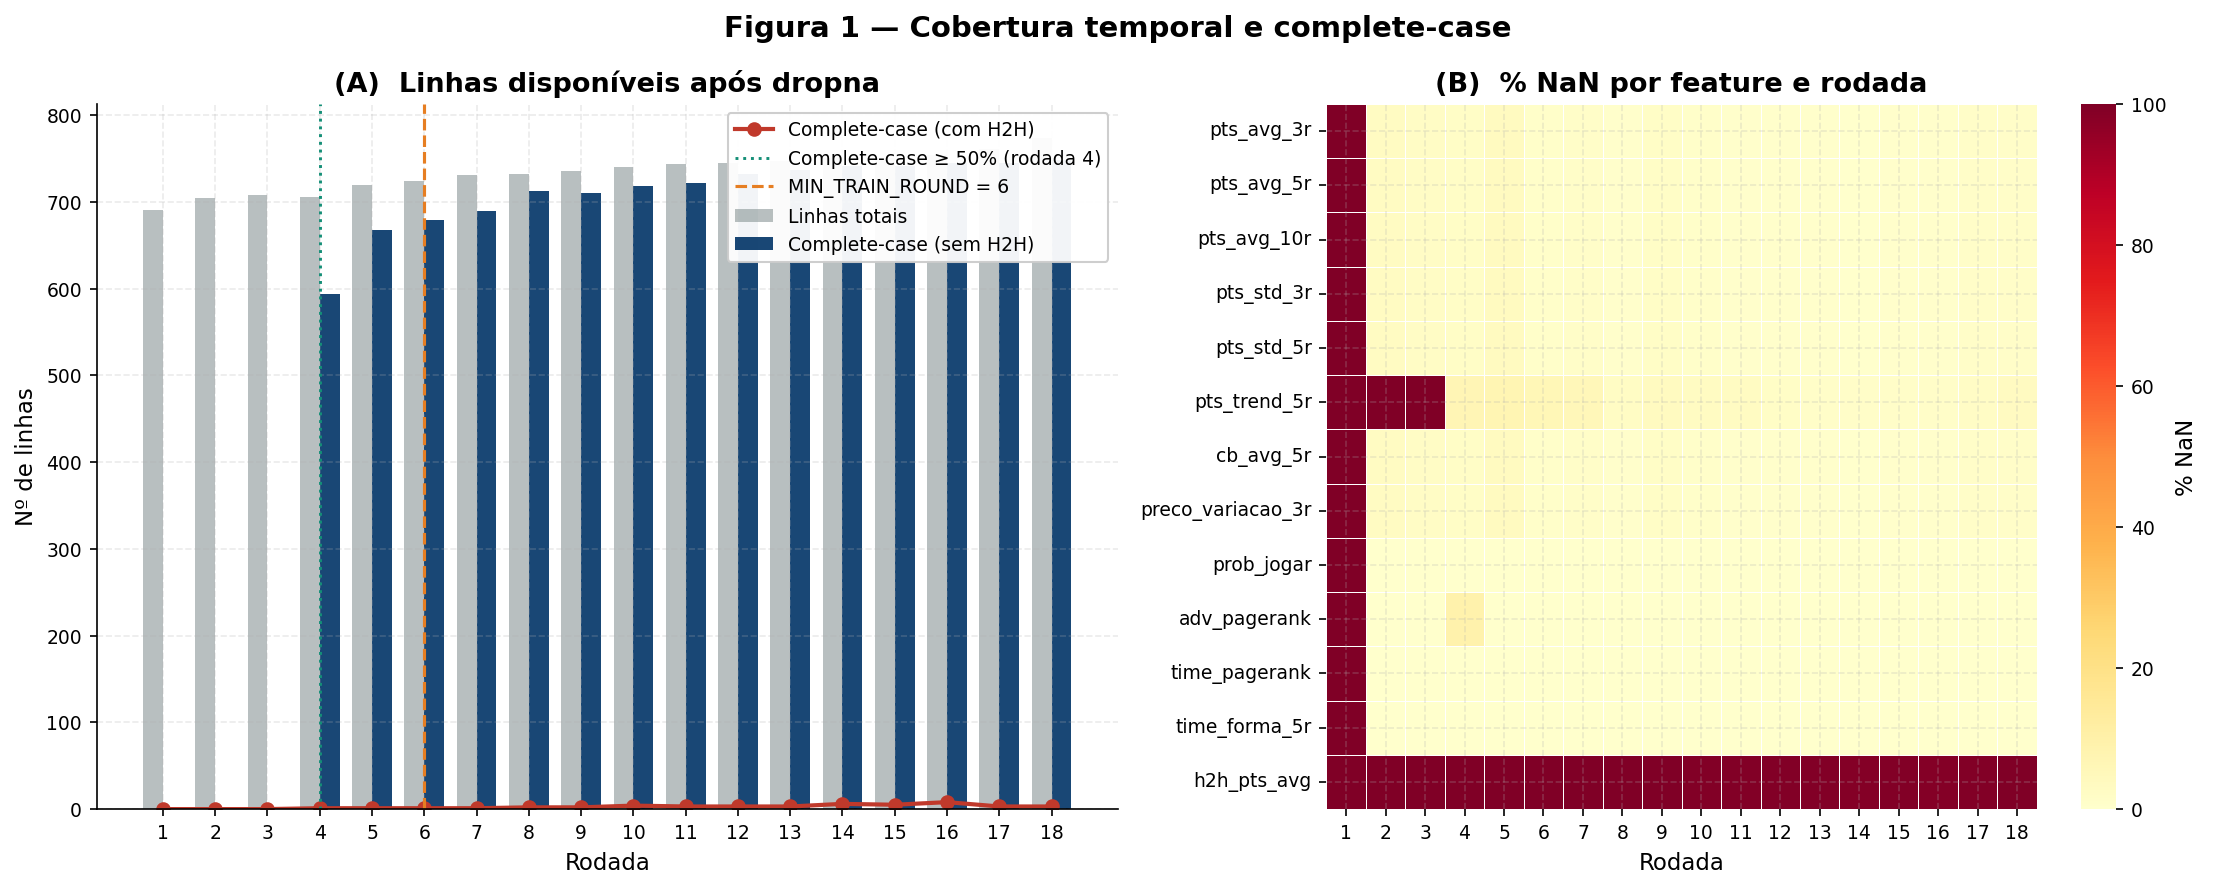

In [2]:
nan_rate = (
    df[MODEL_FEATURES]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("pct_nan")
    .to_frame()
)
nan_rate["n_nan"] = df[MODEL_FEATURES].isna().sum().reindex(nan_rate.index)
nan_rate = nan_rate.round(2)
print("NaN rate by feature (top 25)")
display(nan_rate.head(25))

coverage_rows = []
for round_id, group in df.groupby("rodada_id"):
    n_total = len(group)
    n_core = int(group[CORE_FEATURES].notna().all(axis=1).sum())
    n_with_h2h = int(group[CORE_FEATURES + ["h2h_pts_avg"]].notna().all(axis=1).sum())
    coverage_rows.append(
        {
            "rodada_id": int(round_id),
            "n_total": n_total,
            "n_core": n_core,
            "pct_core": 100 * n_core / n_total,
            "n_with_h2h": n_with_h2h,
            "pct_with_h2h": 100 * n_with_h2h / n_total,
        }
    )
coverage = pd.DataFrame(coverage_rows)
print("\nComplete-case coverage by round")
display(coverage.round(1))

eligible = coverage.loc[coverage["pct_core"] >= 50, "rodada_id"]
FIRST_COMPLETE_ROUND = int(eligible.min()) if len(eligible) else 6
# Complete-case opens as soon as trend/std windows exist, but PageRank/Elo are still
# volatile (section 5.3.5) and fase_campeonato already cuts at round 6.
MIN_TRAIN_ROUND = 6
print(
    f"\nFIRST_COMPLETE_ROUND = {FIRST_COMPLETE_ROUND} "
    "(first round with >= 50% complete-case on CORE_FEATURES)"
)
print(
    f"MIN_TRAIN_ROUND = {MIN_TRAIN_ROUND} "
    "(walk-forward start: complete-case + rating stability)"
)
print(
    "trainable rows (CORE_FEATURES, rodada >= MIN_TRAIN_ROUND):",
    int(coverage.loc[coverage["rodada_id"] >= MIN_TRAIN_ROUND, "n_core"].sum()),
    "of",
    int(coverage.loc[coverage["rodada_id"] >= MIN_TRAIN_ROUND, "n_total"].sum()),
)

NAN_HEATMAP_FEATURES = [
    "pts_avg_3r",
    "pts_avg_5r",
    "pts_avg_10r",
    "pts_std_3r",
    "pts_std_5r",
    "pts_trend_5r",
    "cb_avg_5r",
    "preco_variacao_3r",
    "prob_jogar",
    "adv_pagerank",
    "time_pagerank",
    "time_forma_5r",
    "h2h_pts_avg",
]
nan_by_round = (
    df.groupby("rodada_id")[NAN_HEATMAP_FEATURES]
    .apply(lambda g: g.isna().mean() * 100)
    .T
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.15, 1]})
fig.patch.set_facecolor("white")

ax = axes[0]
x = np.arange(len(coverage))
width = 0.38
ax.bar(x - width / 2, coverage["n_total"], width=width, color=CINZA, alpha=0.55, label="Linhas totais")
ax.bar(x + width / 2, coverage["n_core"], width=width, color=AZUL, alpha=0.9, label="Complete-case (sem H2H)")
ax.plot(x, coverage["n_with_h2h"], color=VERMELHO, marker="o", linewidth=2, label="Complete-case (com H2H)")
ax.axvline(
    FIRST_COMPLETE_ROUND - 1,
    color=CIANO,
    linestyle=":",
    linewidth=1.4,
    label=f"Complete-case ≥ 50% (rodada {FIRST_COMPLETE_ROUND})",
)
ax.axvline(
    MIN_TRAIN_ROUND - 1,
    color=LARANJA,
    linestyle="--",
    linewidth=1.5,
    label=f"MIN_TRAIN_ROUND = {MIN_TRAIN_ROUND}",
)
ax.set_xticks(x)
ax.set_xticklabels(coverage["rodada_id"])
ax.set_xlabel("Rodada")
ax.set_ylabel("Nº de linhas")
ax.set_title("(A)  Linhas disponíveis após dropna", fontweight="bold")
ax.legend(framealpha=0.95, loc="upper right")

ax2 = axes[1]
sns.heatmap(
    nan_by_round,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    ax=ax2,
    cbar_kws={"label": "% NaN"},
    linewidths=0.3,
    linecolor="white",
)
ax2.set_xlabel("Rodada")
ax2.set_ylabel("")
ax2.set_title("(B)  % NaN por feature e rodada", fontweight="bold")

fig.suptitle("Figura 1 — Cobertura temporal e complete-case", fontweight="bold", fontsize=14)
fig.tight_layout()
save_fig(fig, "fig1_nan_cobertura.png")


**Implicação metodológica.** As rodadas 1–3 têm complete-case zero: não há histórico do atleta, o PageRank ainda não existe e `pts_trend_5r` exige ao menos três aparições. A partir da rodada 4 a cobertura salta para ~84% — isso **não é um defeito do pipeline**, é o resultado que se reporta. O walk-forward mesmo assim começa em `MIN_TRAIN_ROUND = 6`: as médias móveis de 5 jogos estão maduras para quem joga regularmente, o PageRank/Elo ainda oscilam nas rodadas 2–5 (seção 5.3.5) e `fase_campeonato` já usa esse corte. A linha vermelha do painel A antecipa a 5.3.4: exigir H2H sem imputar destrói o N no primeiro turno.


## 5.3.2 Correlação de Spearman com `pontos_num`

Spearman pairwise (sem dropna global) entre cada feature e o target, no recorte `rodada_id >= MIN_TRAIN_ROUND`. Três usos no TCC: (1) confirmar que as features construídas têm sinal preditivo, (2) obter um ranking *antes* de treinar qualquer modelo, (3) comparar depois com o feature importance do XGBoost — concordância entre as duas listas é evidência de robustez.


Spearman vs pontos_num | rodada_id >= 6


,feature,rho,abs_rho,pval,n
0,pts_avg_10r,0.4886,0.4886,0.0000,9606
1,pts_avg_5r,0.4868,0.4868,0.0000,9606
2,pts_max_5r,0.4786,0.4786,0.0000,9606
3,pts_avg_3r,0.4733,0.4733,0.0000,9606
4,prop_jogou,0.4710,0.4710,0.0000,9687
5,pts_std_3r,0.4608,0.4608,0.0000,9606
6,pts_std_5r,0.4588,0.4588,0.0000,9606
7,cb_avg_5r,0.4577,0.4577,0.0000,9606
8,pts_median_5r,0.4510,0.4510,0.0000,9606
9,prob_jogar,0.4463,0.4463,0.0000,9687


[OK] saved data\eda\features\fig2_spearman_target.png


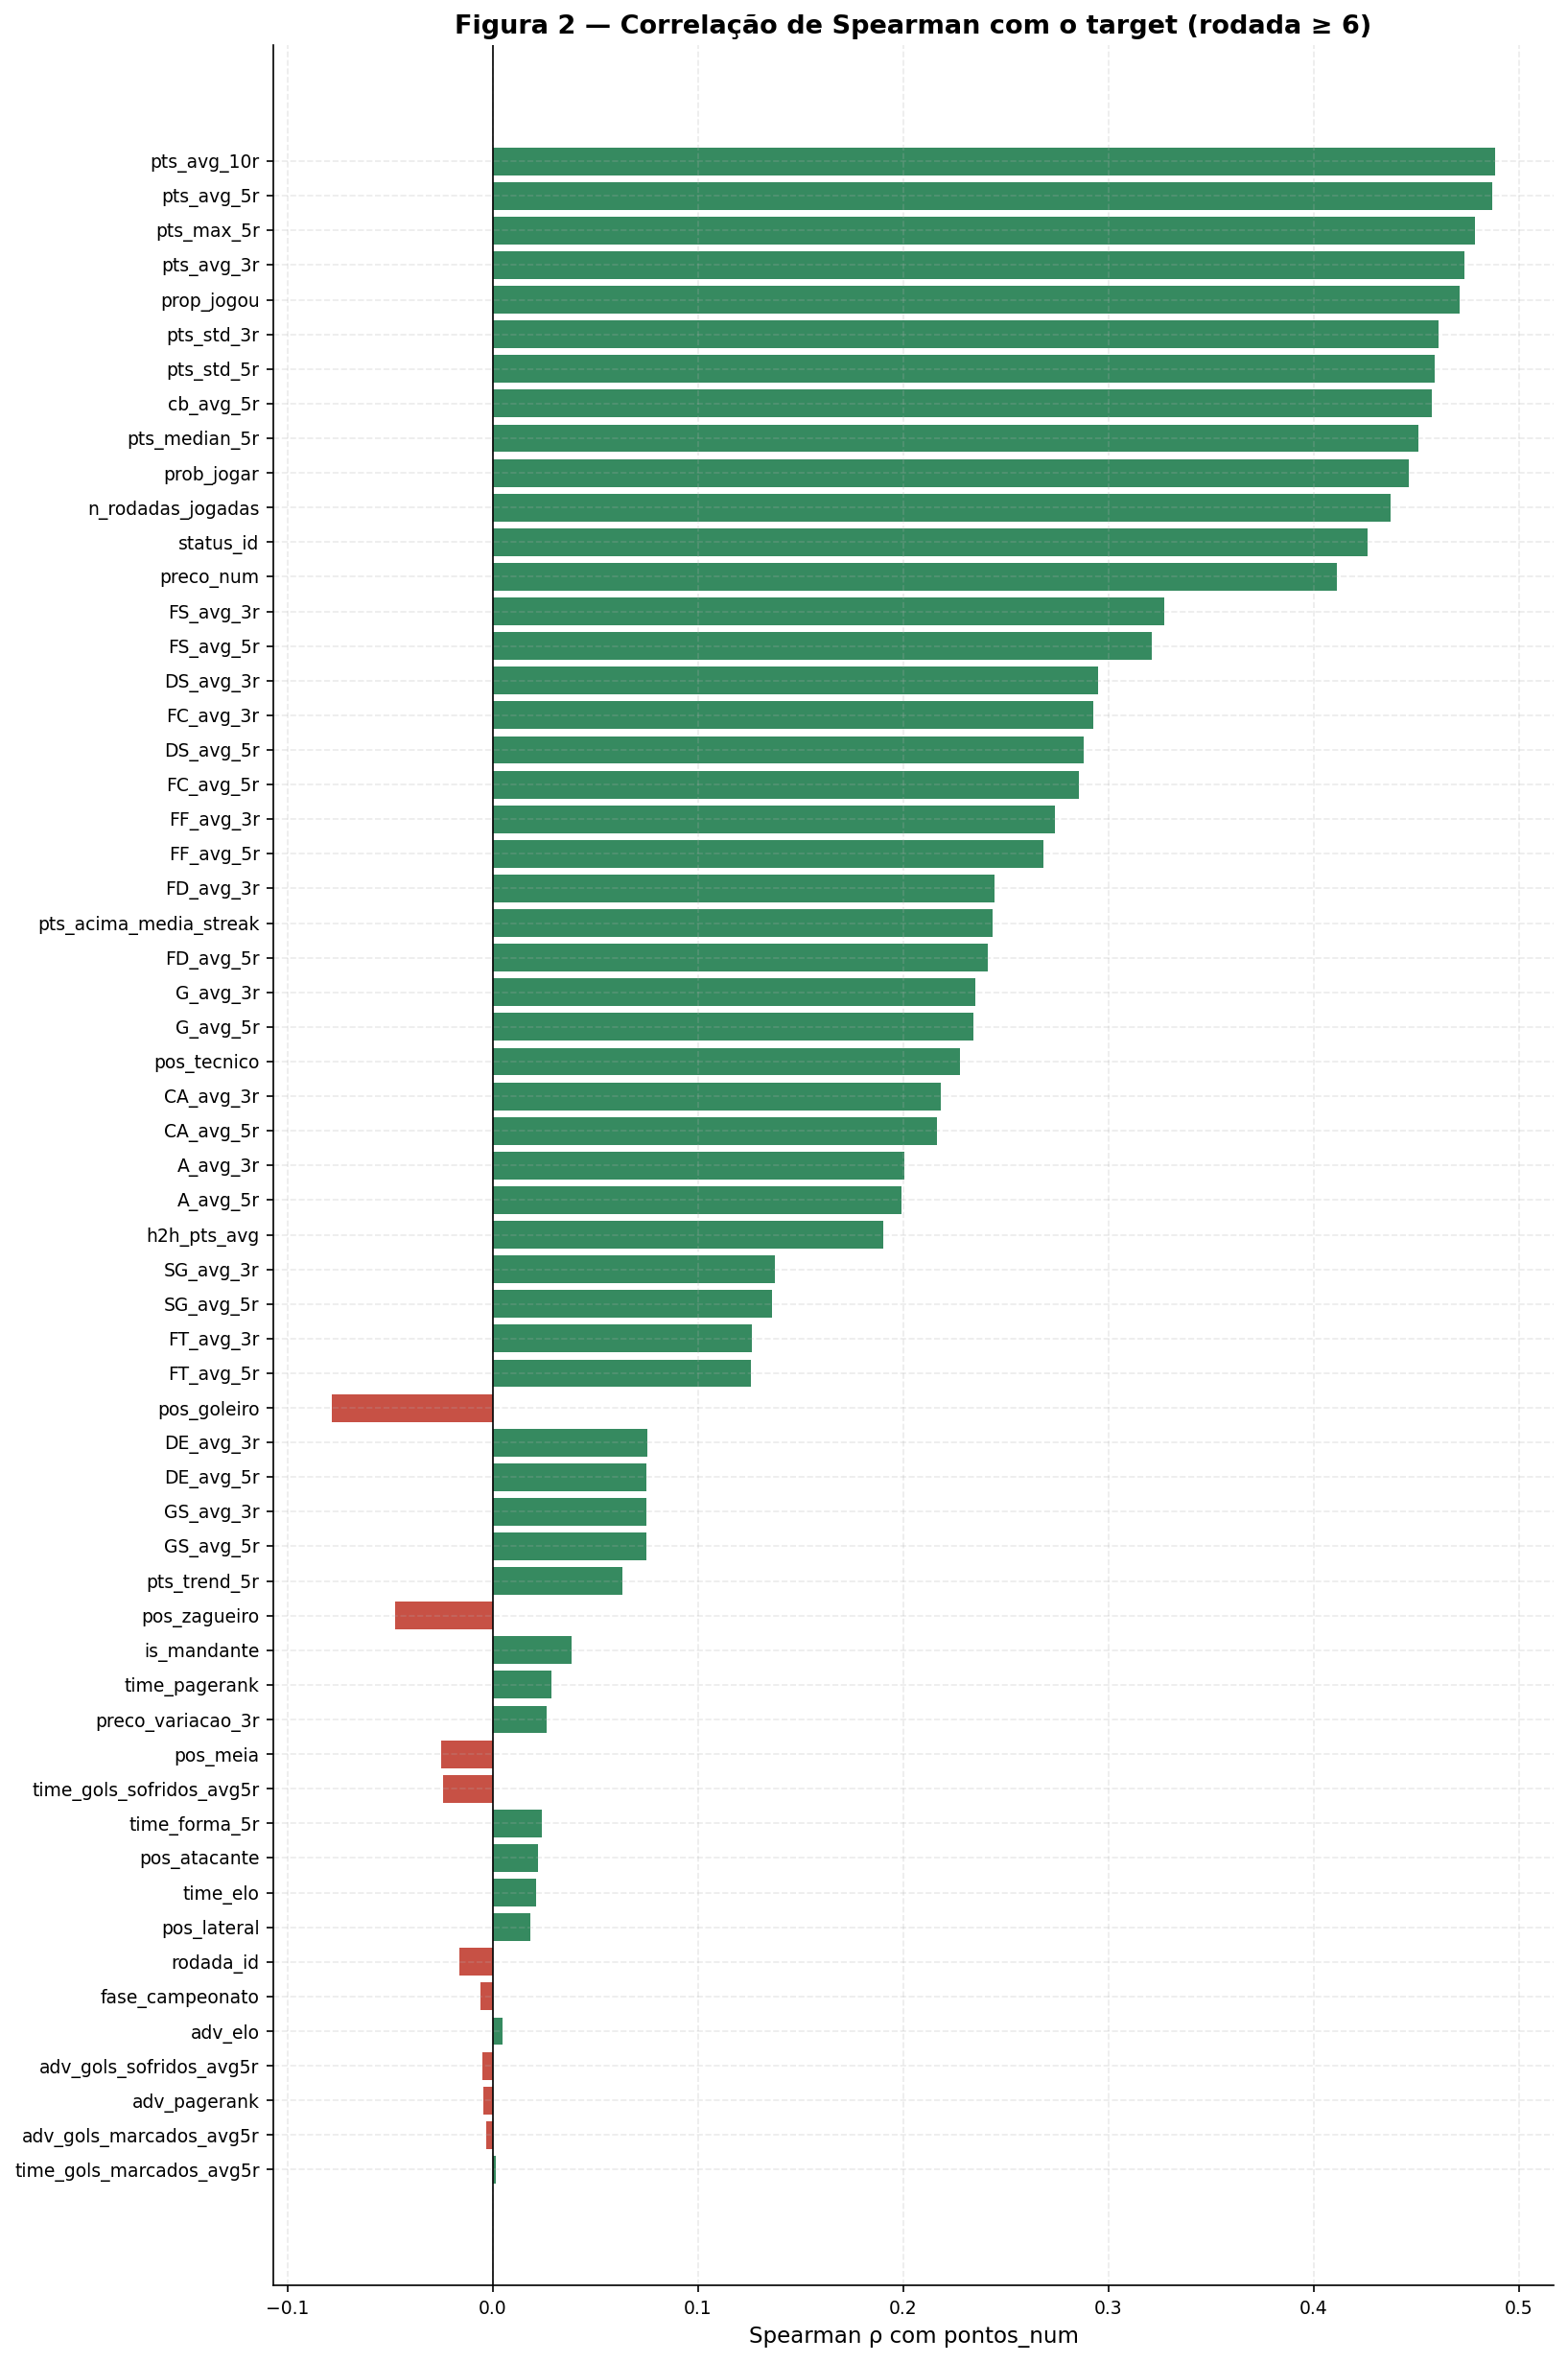

In [3]:
df_model = df.loc[df["rodada_id"] >= MIN_TRAIN_ROUND].copy()


def spearman_vs_target(frame: pd.DataFrame, columns: list[str], target: str = TARGET) -> pd.DataFrame:
    rows = []
    for column in columns:
        pair = frame[[column, target]].dropna()
        n_obs = len(pair)
        if n_obs < 30 or pair[column].nunique() < 2:
            rows.append({"feature": column, "rho": np.nan, "abs_rho": np.nan, "pval": np.nan, "n": n_obs})
            continue
        rho, pval = stats.spearmanr(pair[column], pair[target])
        rows.append({"feature": column, "rho": rho, "abs_rho": abs(rho), "pval": pval, "n": n_obs})
    return pd.DataFrame(rows).sort_values("abs_rho", ascending=False, ignore_index=True)


spearman_rank = spearman_vs_target(df_model, MODEL_FEATURES)
print(f"Spearman vs {TARGET} | rodada_id >= {MIN_TRAIN_ROUND}")
display(spearman_rank.round(4))

plot_rank = spearman_rank.dropna(subset=["rho"]).sort_values("abs_rho", ascending=True)
colors = [VERDE if rho >= 0 else VERMELHO for rho in plot_rank["rho"]]

fig, ax = plt.subplots(figsize=(11, max(8, 0.28 * len(plot_rank))))
fig.patch.set_facecolor("white")
ax.barh(plot_rank["feature"], plot_rank["rho"], color=colors, alpha=0.88)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman ρ com pontos_num")
ax.set_title(
    f"Figura 2 — Correlação de Spearman com o target (rodada ≥ {MIN_TRAIN_ROUND})",
    fontweight="bold",
)
fig.tight_layout()
save_fig(fig, "fig2_spearman_target.png")


**Implicação metodológica.** Features de forma (`pts_avg_*`, `preco_num`, `cb_avg_5r`, `prob_jogar`) devem liderar o ranking se a engenharia da 5.2 capturou sinal real. Esse ordenamento entra no texto como validação pré-modelo e como **baseline** para o importance do XGBoost na seção 5.4: se as duas listas concordam nos líderes, a evidência é robusta à família do estimador.


## 5.3.3 Multicolinearidade entre features

Heatmap de Spearman **entre as próprias features** (não com o target). O cluster `pts_avg_3r`, `pts_avg_5r` e `pts_avg_10r` é esperado — são a mesma série em janelas sobrepostas. A implicação acadêmica é assimétrica: modelos lineares (Ridge/Lasso) sofrem e precisam de regularização forte; árvores (XGBoost) são naturalmente robustas a multicolinearidade. Isso motiva as escolhas da seção 5.4.


Pairs with |Spearman ρ| > 0.80


,feature_a,feature_b,rho
0,DE_avg_5r,GS_avg_5r,1.000
1,pts_std_5r,pts_max_5r,0.983
2,pts_avg_5r,cb_avg_5r,0.969
3,pts_avg_5r,pts_max_5r,0.963
4,prop_jogou,n_rodadas_jogadas,0.943
5,pts_max_5r,cb_avg_5r,0.928
6,pts_avg_10r,prop_jogou,0.921
7,pts_avg_5r,pts_avg_10r,0.915
8,pts_avg_5r,pts_std_5r,0.915
9,pts_avg_3r,pts_avg_5r,0.900


[OK] saved data\eda\features\fig3_multicolinearidade.png


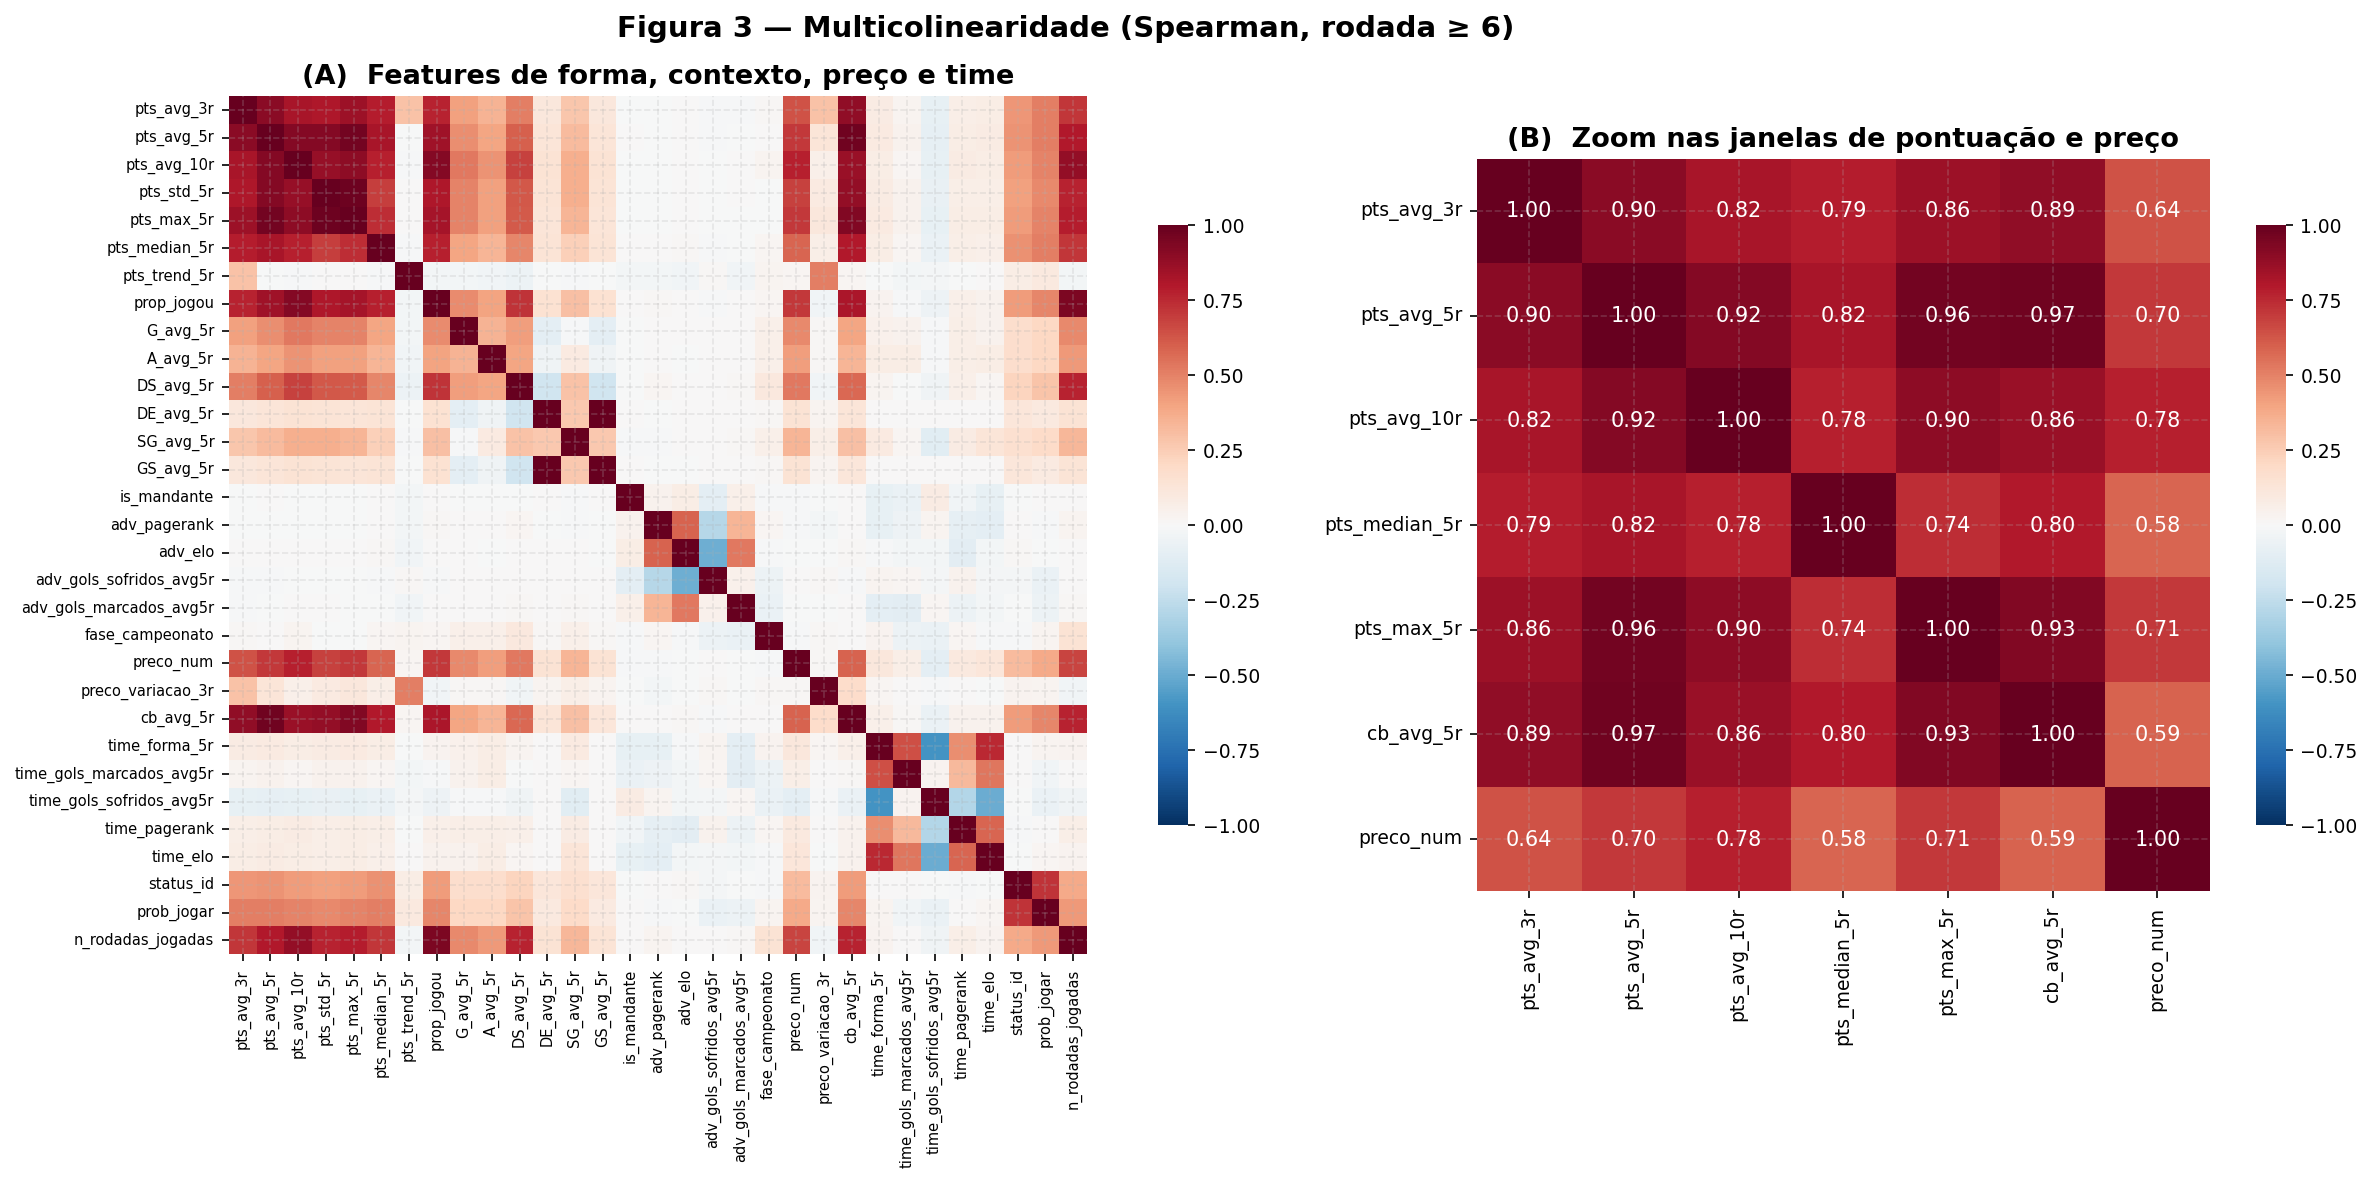

In [4]:
HEATMAP_FEATURES = [
    "pts_avg_3r",
    "pts_avg_5r",
    "pts_avg_10r",
    "pts_std_5r",
    "pts_max_5r",
    "pts_median_5r",
    "pts_trend_5r",
    "prop_jogou",
    "G_avg_5r",
    "A_avg_5r",
    "DS_avg_5r",
    "DE_avg_5r",
    "SG_avg_5r",
    "GS_avg_5r",
    "is_mandante",
    "adv_pagerank",
    "adv_elo",
    "adv_gols_sofridos_avg5r",
    "adv_gols_marcados_avg5r",
    "fase_campeonato",
    "preco_num",
    "preco_variacao_3r",
    "cb_avg_5r",
    "time_forma_5r",
    "time_gols_marcados_avg5r",
    "time_gols_sofridos_avg5r",
    "time_pagerank",
    "time_elo",
    "status_id",
    "prob_jogar",
    "n_rodadas_jogadas",
]
ZOOM_FEATURES = [
    "pts_avg_3r",
    "pts_avg_5r",
    "pts_avg_10r",
    "pts_median_5r",
    "pts_max_5r",
    "cb_avg_5r",
    "preco_num",
]

df_complete = df_model.dropna(subset=CORE_FEATURES)
corr_all = df_complete[HEATMAP_FEATURES].corr(method="spearman")
corr_zoom = df_complete[ZOOM_FEATURES].corr(method="spearman")

pair_rows = []
for left, right in combinations(HEATMAP_FEATURES, 2):
    rho = corr_all.loc[left, right]
    if abs(rho) > 0.80:
        pair_rows.append({"feature_a": left, "feature_b": right, "rho": rho})
high_pairs = pd.DataFrame(pair_rows, columns=["feature_a", "feature_b", "rho"])
if len(high_pairs):
    high_pairs = high_pairs.sort_values("rho", key=np.abs, ascending=False, ignore_index=True)
print("Pairs with |Spearman ρ| > 0.80")
display(high_pairs.round(3) if len(high_pairs) else pd.DataFrame(columns=["feature_a", "feature_b", "rho"]))

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.55, 1]})
fig.patch.set_facecolor("white")

sns.heatmap(
    corr_all,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
    square=True,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"shrink": 0.7},
)
axes[0].tick_params(axis="x", rotation=90, labelsize=7)
axes[0].tick_params(axis="y", labelsize=7)
axes[0].set_title("(A)  Features de forma, contexto, preço e time", fontweight="bold")

sns.heatmap(
    corr_zoom,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    ax=axes[1],
    square=True,
    cbar_kws={"shrink": 0.7},
)
axes[1].set_title("(B)  Zoom nas janelas de pontuação e preço", fontweight="bold")

fig.suptitle(
    f"Figura 3 — Multicolinearidade (Spearman, rodada ≥ {MIN_TRAIN_ROUND})",
    fontweight="bold",
    fontsize=14,
)
fig.tight_layout()
save_fig(fig, "fig3_multicolinearidade.png")


**Implicação metodológica.** Alta correlação entre `pts_avg_3r`, `pts_avg_5r` e `pts_avg_10r` é o comportamento esperado de médias móveis sobrepostas, não um erro de especificação. Em regressão linear isso infla variância dos coeficientes — Ridge/Lasso precisam de regularização forte (ou de uma única janela). Modelos de árvore particionam o espaço e **não exigem ortogonalidade**, o que justifica priorizar XGBoost na seção 5.4 sem descartar as três janelas a priori.


## 5.3.4 Distribuição de cobertura do H2H

`h2h_pts_avg` é a média de pontos do atleta contra o mesmo adversário no passado. No primeiro turno de um Brasileirão de 20 clubes quase não há reencontro, então a feature fica NaN na maior parte das linhas. Aqui o trade-off é quantificado: **incluir H2H e dropar NaN reduz drasticamente o dataset de treino**.


H2H coverage


,recorte,n_linhas,n_h2h_observado,pct_nan
0,Todas as rodadas,13215,46,99.65
1,rodada_id >= 6,9687,44,99.55


,rodada_id,n_total,n_nan,n_observed,pct_nan,pct_observed
0,1,691,691,0,100.0,0.0
1,2,704,704,0,100.0,0.0
2,3,708,708,0,100.0,0.0
3,4,706,705,1,99.9,0.1
4,5,719,718,1,99.9,0.1
5,6,724,723,1,99.9,0.1
6,7,731,730,1,99.9,0.1
7,8,732,730,2,99.7,0.3
8,9,736,734,2,99.7,0.3
9,10,740,736,4,99.5,0.5


[OK] saved data\eda\features\fig4_h2h_cobertura.png


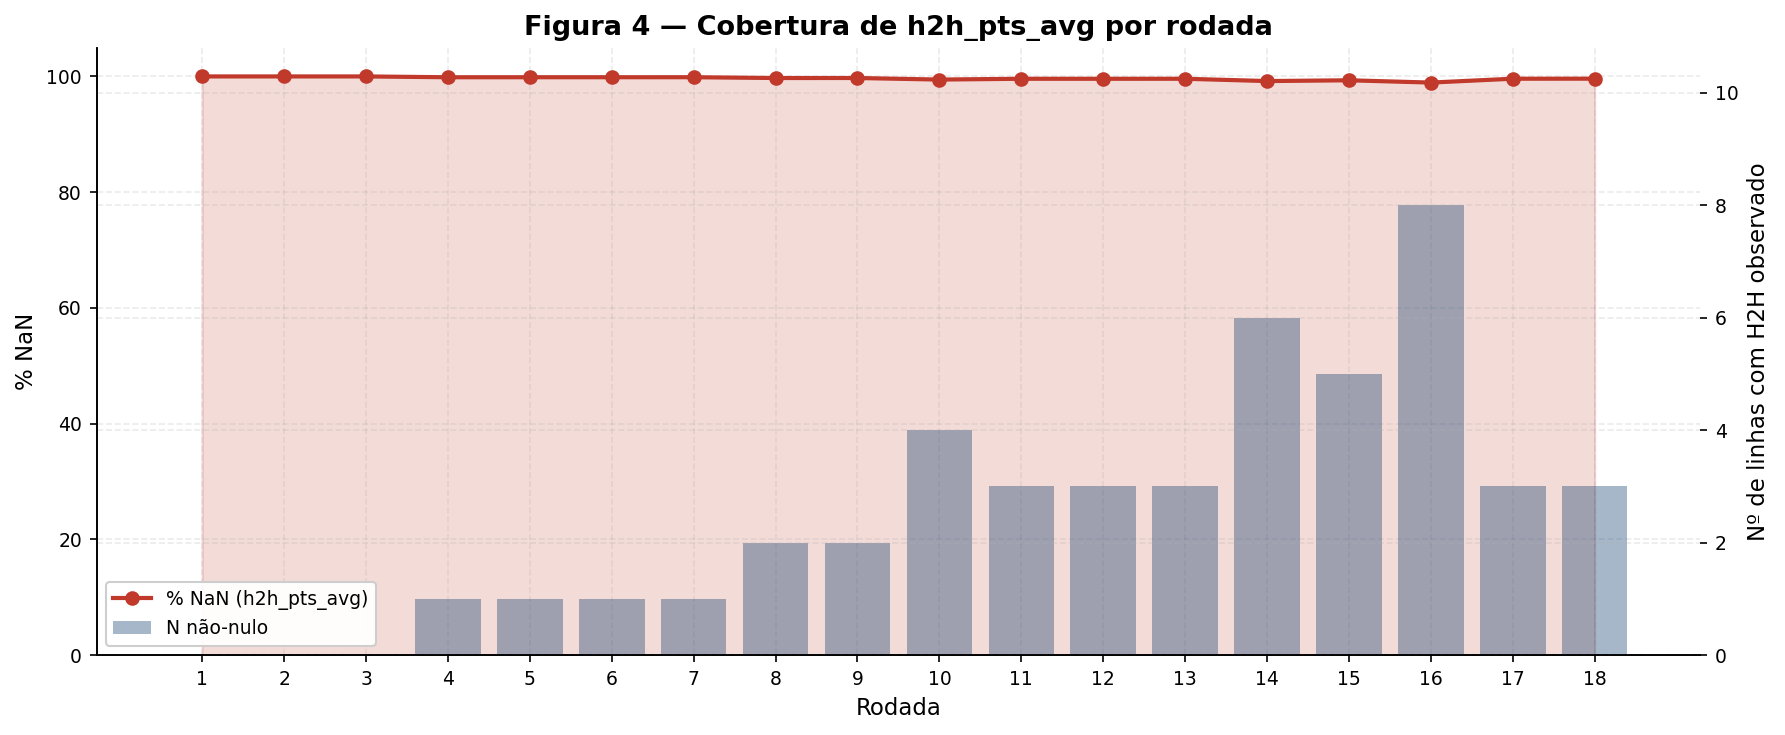

In [5]:
h2h_by_round = (
    df.groupby("rodada_id")
    .agg(
        n_total=("h2h_pts_avg", "size"),
        n_nan=("h2h_pts_avg", lambda s: int(s.isna().sum())),
        n_observed=("h2h_pts_avg", lambda s: int(s.notna().sum())),
    )
    .reset_index()
)
h2h_by_round["pct_nan"] = 100 * h2h_by_round["n_nan"] / h2h_by_round["n_total"]
h2h_by_round["pct_observed"] = 100 * h2h_by_round["n_observed"] / h2h_by_round["n_total"]

summary_h2h = pd.DataFrame(
    {
        "recorte": ["Todas as rodadas", f"rodada_id >= {MIN_TRAIN_ROUND}"],
        "n_linhas": [
            len(df),
            int((df["rodada_id"] >= MIN_TRAIN_ROUND).sum()),
        ],
        "n_h2h_observado": [
            int(df["h2h_pts_avg"].notna().sum()),
            int(df.loc[df["rodada_id"] >= MIN_TRAIN_ROUND, "h2h_pts_avg"].notna().sum()),
        ],
    }
)
summary_h2h["pct_nan"] = 100 * (1 - summary_h2h["n_h2h_observado"] / summary_h2h["n_linhas"])
print("H2H coverage")
display(summary_h2h.round(2))
display(h2h_by_round.round(1))

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.fill_between(h2h_by_round["rodada_id"], h2h_by_round["pct_nan"], color=VERMELHO, alpha=0.18)
ax.plot(
    h2h_by_round["rodada_id"],
    h2h_by_round["pct_nan"],
    color=VERMELHO,
    marker="o",
    linewidth=2,
    label="% NaN (h2h_pts_avg)",
)
ax.set_xlabel("Rodada")
ax.set_ylabel("% NaN")
ax.set_ylim(0, 105)
ax.set_xticks(h2h_by_round["rodada_id"])
ax2 = ax.twinx()
ax2.bar(
    h2h_by_round["rodada_id"],
    h2h_by_round["n_observed"],
    color=AZUL,
    alpha=0.35,
    label="N não-nulo",
)
ax2.spines["top"].set_visible(False)
ax2.set_ylabel("Nº de linhas com H2H observado")
ymax_obs = max(float(h2h_by_round["n_observed"].max()) * 1.35, 10.0)
ax2.set_ylim(0, ymax_obs)
handles, labels = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles + handles2, labels + labels2, loc="lower left", framealpha=0.95)
ax.set_title("Figura 4 — Cobertura de h2h_pts_avg por rodada", fontweight="bold")
fig.tight_layout()
save_fig(fig, "fig4_h2h_cobertura.png")


**Implicação metodológica.** Exigir H2H em complete-case inviabiliza o treino no primeiro turno. O trade-off relevante para a 5.4 é: **imputar** (por exemplo com `pts_avg_5r`, a média geral recente do atleta) em vez de dropar. Esta seção apenas quantifica o custo de dropar; o imputer em si fica para o pipeline de modelagem.


## 5.3.5 Estabilidade do PageRank e do Elo por rodada

PageRank e Elo da rodada `t` são ratings **antes** do jogo, calculados só com partidas `1..t-1`. Visualizar a trajetória dos 20 clubes ao longo das 18 rodadas tem valor narrativo alto: a hierarquia de força se consolida, e no início as métricas são instáveis (poucos jogos). G4 e Z4 da última rodada (ordenados por Elo) são destacados; os demais clubes ficam em cinza.


[OK] saved data\eda\features\fig5_pagerank_elo.png


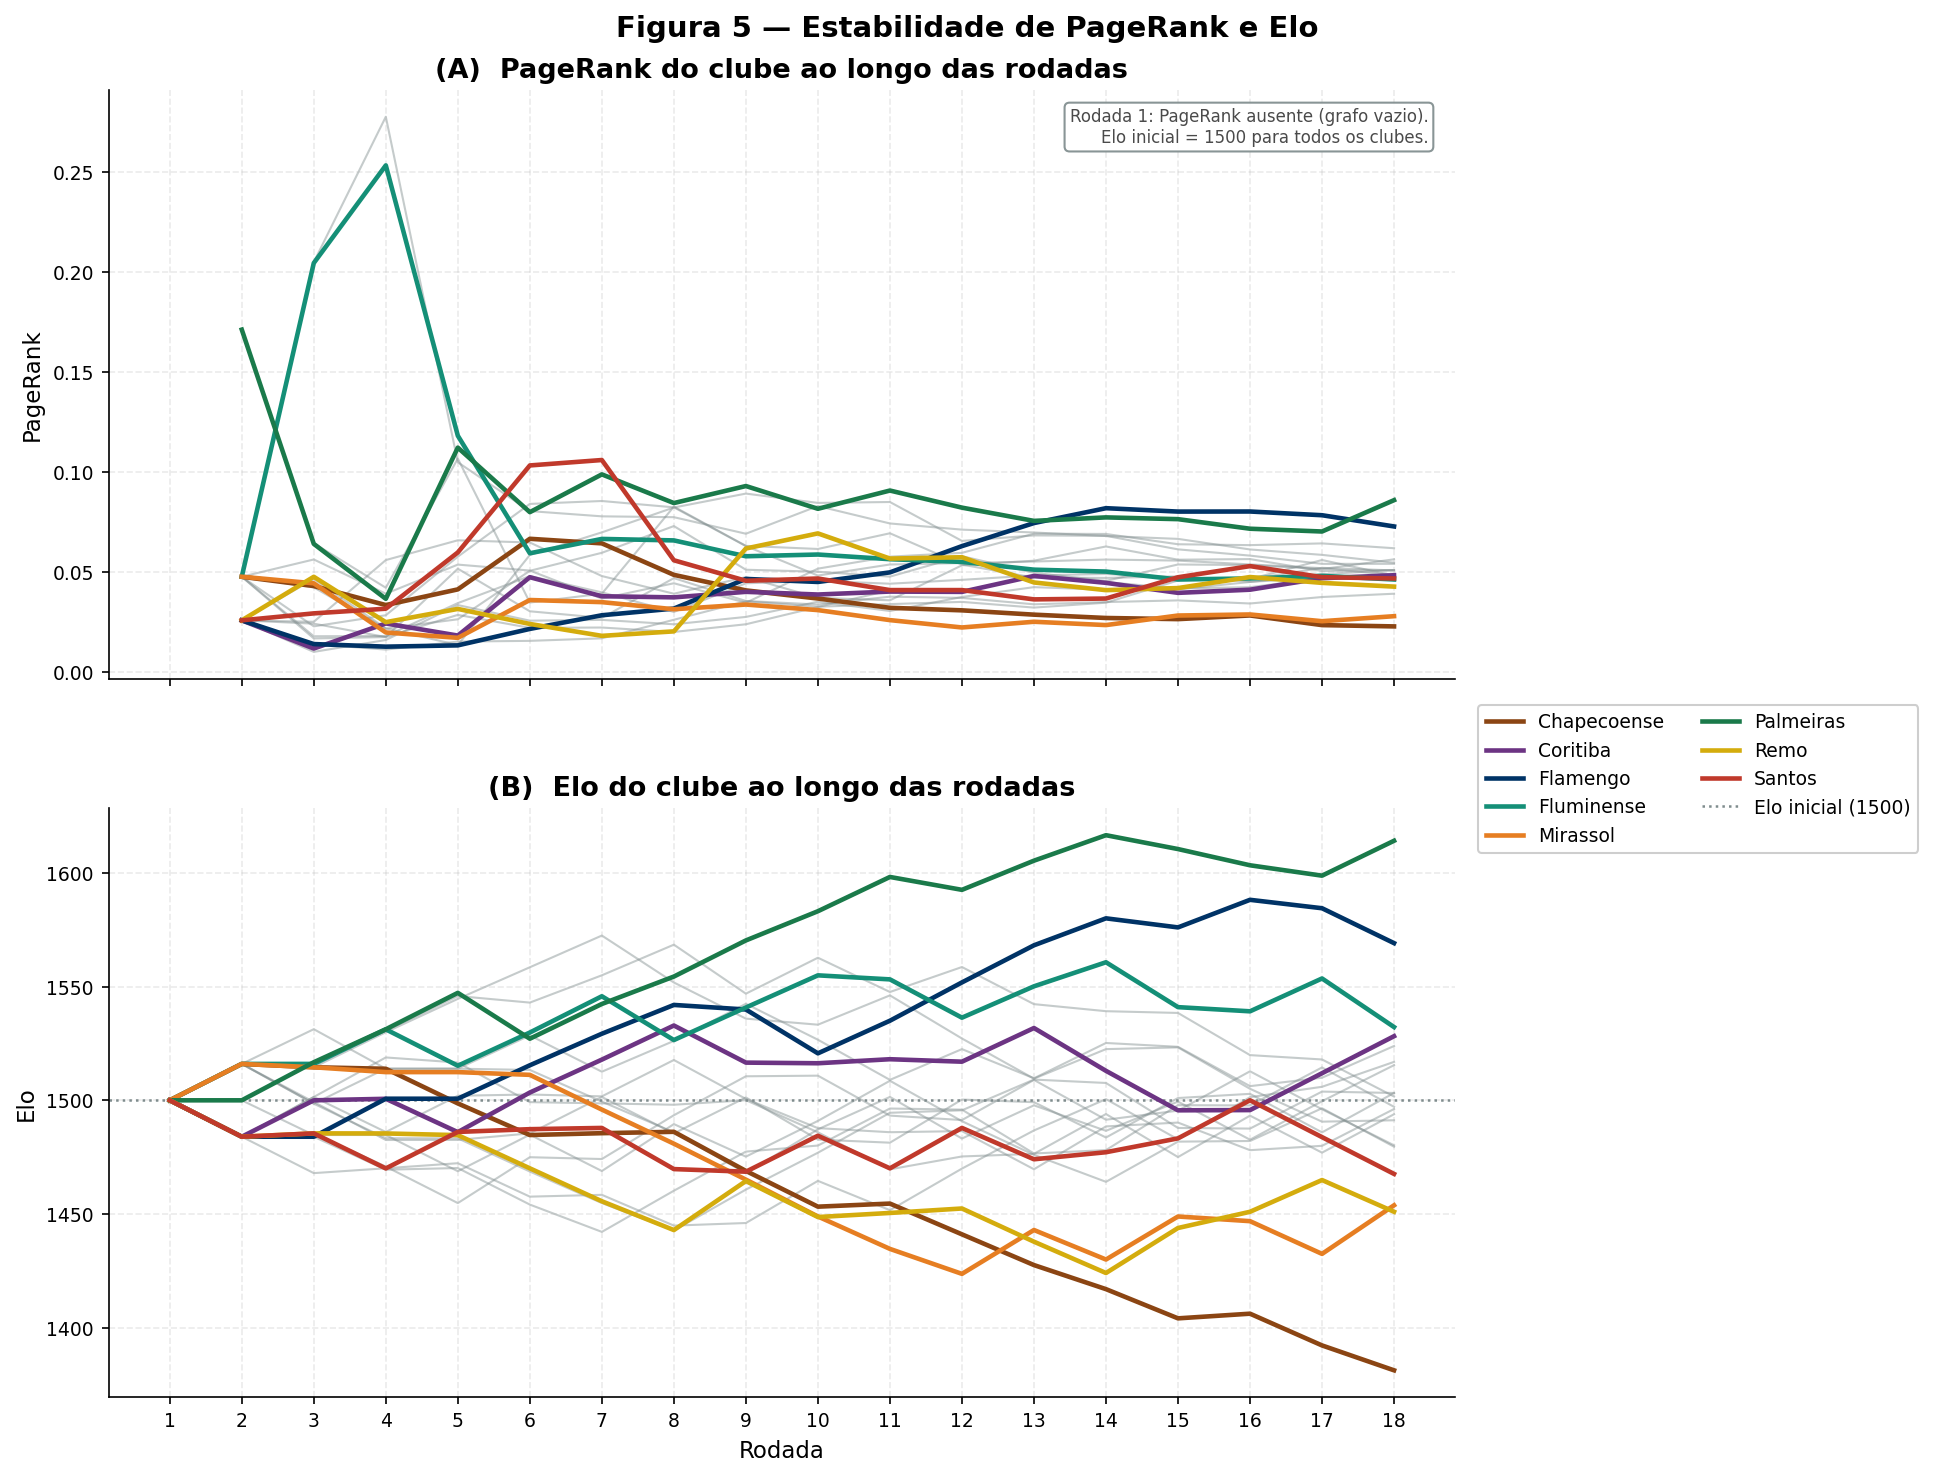

In [6]:
club_home = games[["clube_casa_id", "clube_casa"]].rename(
    columns={"clube_casa_id": "clube_id", "clube_casa": "clube"}
)
club_away = games[["clube_visitante_id", "clube_visitante"]].rename(
    columns={"clube_visitante_id": "clube_id", "clube_visitante": "clube"}
)
club_names = pd.concat([club_home, club_away], ignore_index=True).drop_duplicates("clube_id")
club_name_map = dict(zip(club_names["clube_id"], club_names["clube"]))

ratings = (
    df[["rodada_id", "clube_id", "time_pagerank", "time_elo"]]
    .drop_duplicates(["rodada_id", "clube_id"])
    .copy()
)
ratings["clube"] = ratings["clube_id"].map(club_name_map)

last_round = int(ratings["rodada_id"].max())
last_elo = ratings.loc[ratings["rodada_id"] == last_round].sort_values("time_elo", ascending=False)
g4 = last_elo.head(4)["clube"].tolist()
z4 = last_elo.tail(4)["clube"].tolist()
highlight = {name: color for name, color in zip(g4, [VERDE, AZUL, CIANO, ROXO])}
highlight.update({name: color for name, color in zip(z4, [VERMELHO, LARANJA, AMARELO, "#8B4513"])})

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
fig.patch.set_facecolor("white")

for ax, column, ylabel, title in [
    (axes[0], "time_pagerank", "PageRank", "(A)  PageRank do clube ao longo das rodadas"),
    (axes[1], "time_elo", "Elo", "(B)  Elo do clube ao longo das rodadas"),
]:
    for club, group in ratings.groupby("clube"):
        ordered = group.sort_values("rodada_id")
        if club in highlight:
            ax.plot(
                ordered["rodada_id"],
                ordered[column],
                color=highlight[club],
                linewidth=2.2,
                label=club,
                zorder=3,
            )
        else:
            ax.plot(
                ordered["rodada_id"],
                ordered[column],
                color=CINZA,
                linewidth=1.0,
                alpha=0.45,
                zorder=1,
            )
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(sorted(ratings["rodada_id"].unique()))

axes[1].axhline(1500, color=CINZA, linestyle=":", linewidth=1.2, label="Elo inicial (1500)")
axes[1].set_xlabel("Rodada")
axes[0].text(
    0.98,
    0.97,
    "Rodada 1: PageRank ausente (grafo vazio).\nElo inicial = 1500 para todos os clubes.",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=8,
    color="#4A4A4A",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": CINZA, "alpha": 0.92},
)
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, ncol=2, loc="center left", bbox_to_anchor=(1.01, 1.05), framealpha=0.95)
fig.suptitle("Figura 5 — Estabilidade de PageRank e Elo", fontweight="bold", fontsize=14)
fig.tight_layout()
save_fig(fig, "fig5_pagerank_elo.png")


**Implicação metodológica.** No início da temporada as métricas de força do time têm pouco fundamento empírico; elas se separam à medida que o campeonato avança. Isso reduz o poder preditivo de `time_pagerank` / `adv_elo` nas primeiras rodadas e pode ser capturado incluindo `rodada_id` (ou `fase_campeonato`) como feature, ou ponderando amostras recentes no treino.


## 5.3.6 Feature importance prévia via Mutual Information

Antes de treinar qualquer modelo, Mutual Information (`sklearn.feature_selection.mutual_info_regression`) entre cada feature e `pontos_num`. Diferente de Pearson/Spearman, MI captura dependências **não-lineares**. O ranking (a) entra no TCC como EDA das features, (b) pode alimentar feature selection e (c) serve de baseline para o importance pós-treino.


Mutual information vs pontos_num | complete-case, rodada >= 6, n = 9419


,feature,mi,abs_rho,rho,rank_mi,rank_spearman,rank_gap
0,status_id,0.2380,0.4265,0.4265,1,12,11
1,prob_jogar,0.2250,0.4463,0.4463,2,10,8
2,pts_avg_5r,0.2187,0.4868,0.4868,3,2,-1
3,pts_std_5r,0.2171,0.4588,0.4588,4,7,3
4,pts_avg_10r,0.2115,0.4886,0.4886,5,1,-4
5,cb_avg_5r,0.2100,0.4577,0.4577,6,8,2
6,pts_max_5r,0.2073,0.4786,0.4786,7,3,-4
7,pts_std_3r,0.2011,0.4608,0.4608,8,6,-2
8,pts_avg_3r,0.2004,0.4733,0.4733,9,4,-5
9,preco_num,0.1936,0.4111,0.4111,10,13,3


[OK] saved data\eda\features\fig6_mutual_information.png


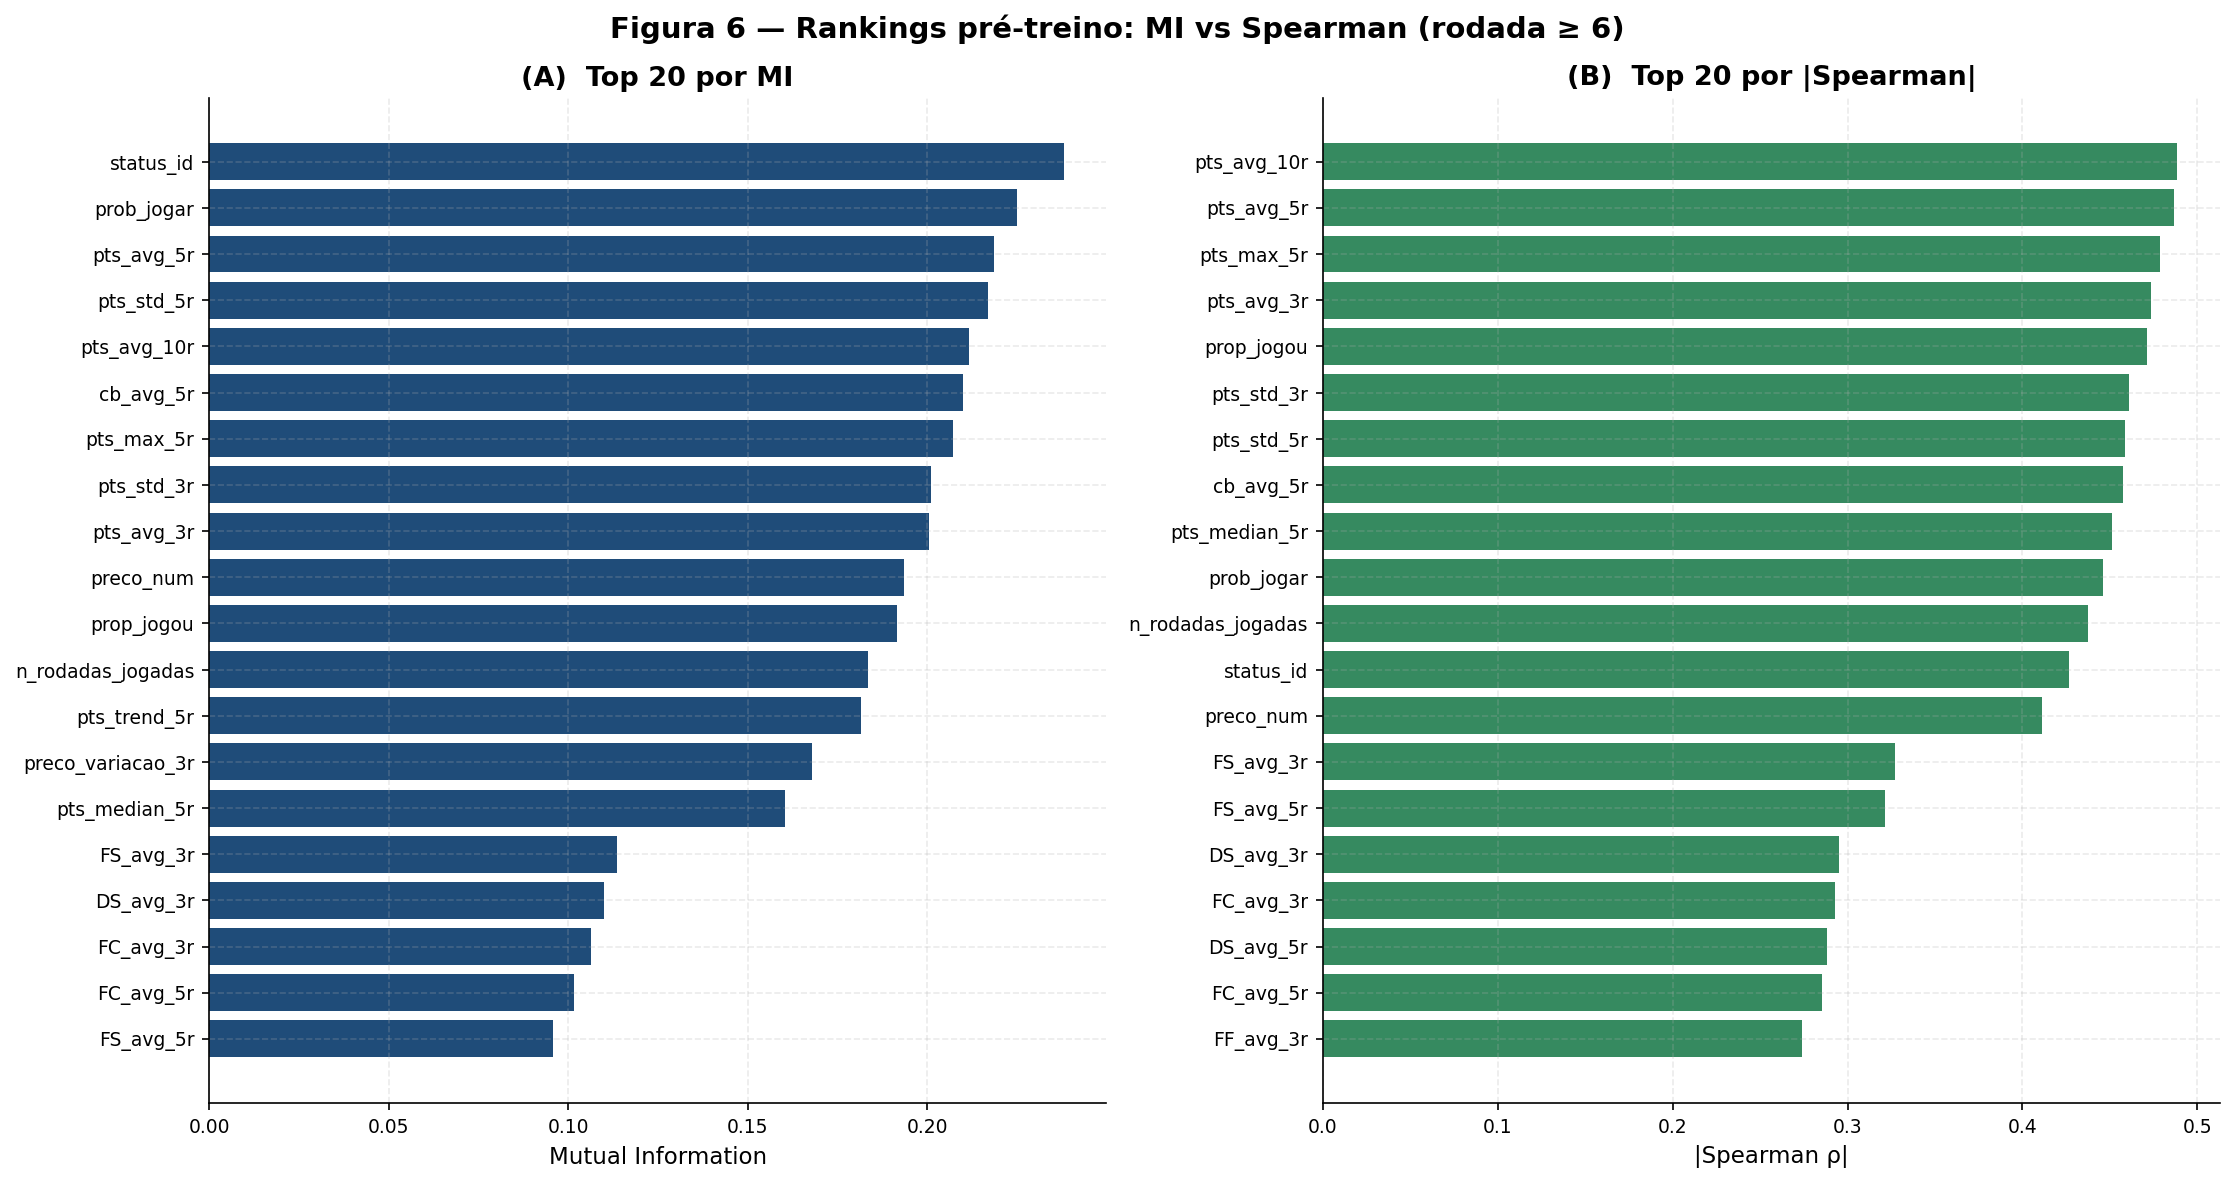

In [7]:
mi_frame = df_complete[CORE_FEATURES + [TARGET]].copy()
X = mi_frame[CORE_FEATURES]
y = mi_frame[TARGET].to_numpy()
discrete_mask = [column in DISCRETE_FEATURES for column in CORE_FEATURES]

mi_values = mutual_info_regression(
    X,
    y,
    discrete_features=discrete_mask,
    random_state=42,
    n_neighbors=3,
)
mi_rank = pd.DataFrame({"feature": CORE_FEATURES, "mi": mi_values}).sort_values(
    "mi", ascending=False, ignore_index=True
)
comparison = mi_rank.merge(spearman_rank[["feature", "abs_rho", "rho"]], on="feature", how="left")
comparison["rank_mi"] = comparison["mi"].rank(ascending=False, method="min").astype(int)
comparison["rank_spearman"] = comparison["abs_rho"].rank(ascending=False, method="min").astype(int)
comparison["rank_gap"] = comparison["rank_spearman"] - comparison["rank_mi"]
print(f"Mutual information vs {TARGET} | complete-case, rodada >= {MIN_TRAIN_ROUND}, n = {len(mi_frame)}")
display(comparison.sort_values("rank_mi").round(4))

top_n = 20
mi_top = comparison.nsmallest(top_n, "rank_mi").sort_values("mi", ascending=True)
sp_top = comparison.nsmallest(top_n, "rank_spearman").sort_values("abs_rho", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.patch.set_facecolor("white")

axes[0].barh(mi_top["feature"], mi_top["mi"], color=AZUL, alpha=0.88)
axes[0].set_xlabel("Mutual Information")
axes[0].set_title(f"(A)  Top {top_n} por MI", fontweight="bold")

axes[1].barh(sp_top["feature"], sp_top["abs_rho"], color=VERDE, alpha=0.88)
axes[1].set_xlabel("|Spearman ρ|")
axes[1].set_title(f"(B)  Top {top_n} por |Spearman|", fontweight="bold")

fig.suptitle(
    f"Figura 6 — Rankings pré-treino: MI vs Spearman (rodada ≥ {MIN_TRAIN_ROUND})",
    fontweight="bold",
    fontsize=14,
)
fig.tight_layout()
save_fig(fig, "fig6_mutual_information.png")


**Implicação metodológica.** Onde MI e Spearman concordam, a associação é essencialmente monotônica. Onde MI sobe e Spearman não, há dependência não-linear que um modelo de árvore pode capturar e uma regressão linear simples perde. Esse ranking é o baseline contra o qual o feature importance do XGBoost será lido na seção 5.4.


## 5.3.7 Distribuição das features por posição

Algumas features têm suporte quase exclusivo de uma posição: `DE_avg_5r` e `GS_avg_5r` são de goleiro; `G_avg_5r` concentra-se em atacantes; `SG_avg_5r` em zagueiros e laterais. Isso torna visual a decisão da seção 5.4: **um modelo por posição** versus **um modelo único com dummies de posição**.


[OK] saved data\eda\features\fig7_features_por_posicao.png


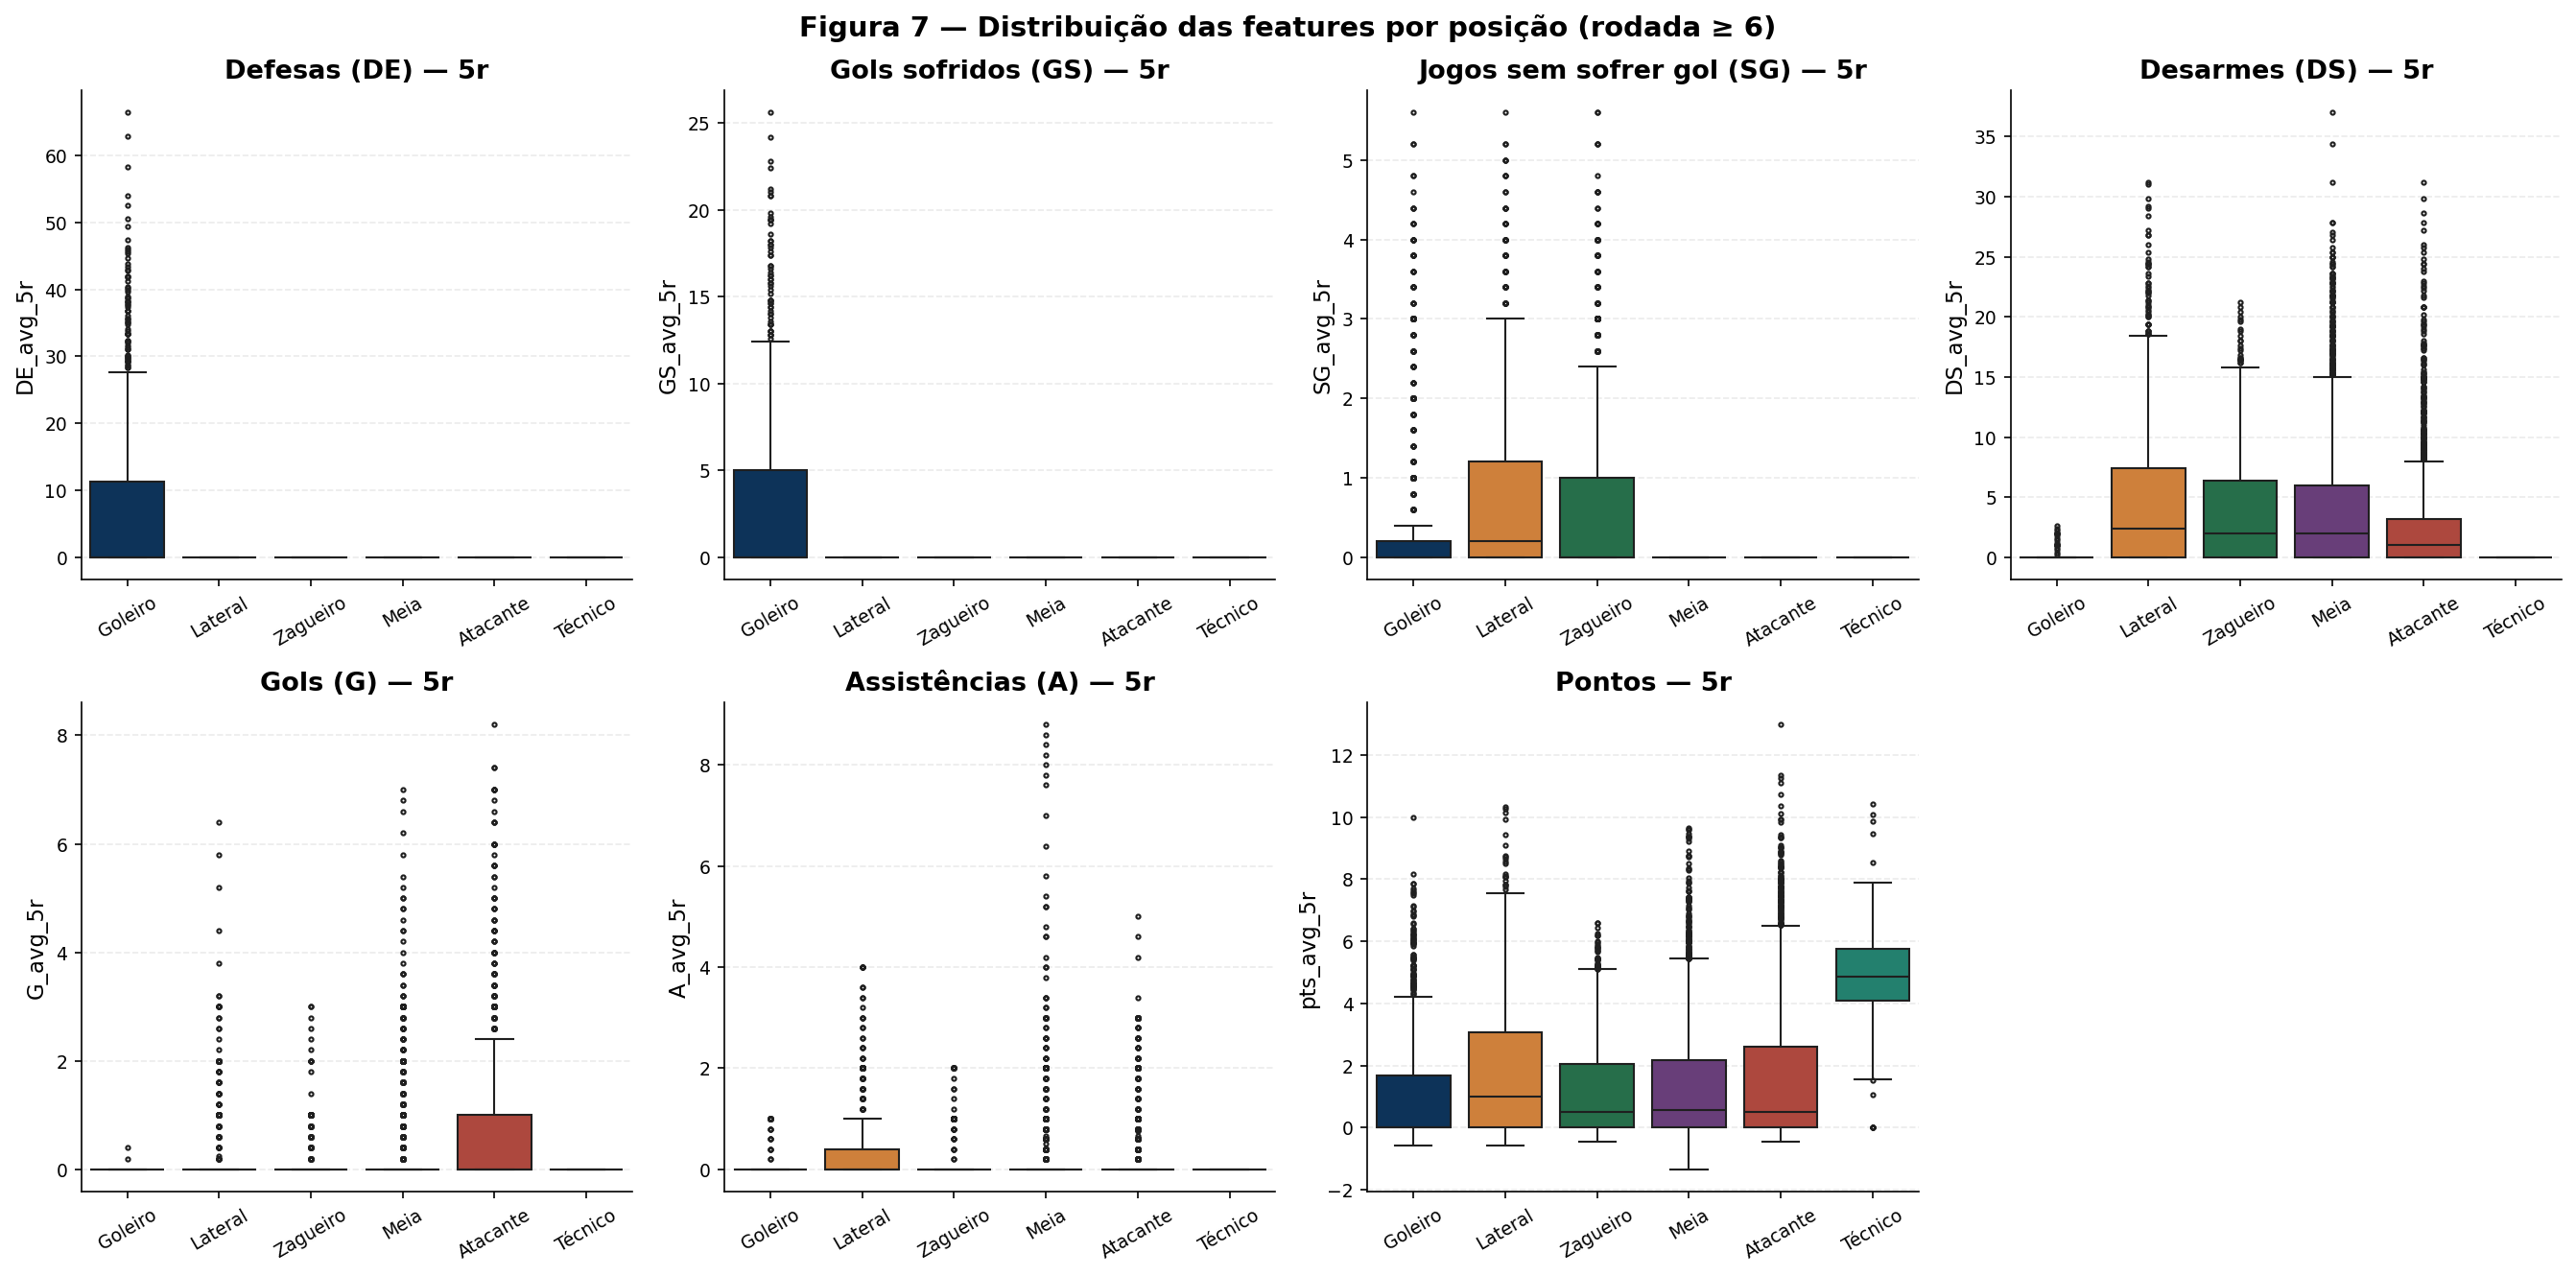

In [8]:
POSITION_FEATURES = [
    ("DE_avg_5r", "Defesas (DE) — 5r"),
    ("GS_avg_5r", "Gols sofridos (GS) — 5r"),
    ("SG_avg_5r", "Jogos sem sofrer gol (SG) — 5r"),
    ("DS_avg_5r", "Desarmes (DS) — 5r"),
    ("G_avg_5r", "Gols (G) — 5r"),
    ("A_avg_5r", "Assistências (A) — 5r"),
    ("pts_avg_5r", "Pontos — 5r"),
]

df_pos = df_model.dropna(subset=[column for column, _ in POSITION_FEATURES]).copy()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor("white")
axes_flat = axes.ravel()

for idx, (column, title) in enumerate(POSITION_FEATURES):
    ax = axes_flat[idx]
    sns.boxplot(
        data=df_pos,
        x="posicao",
        y=column,
        hue="posicao",
        order=POS_ORDER,
        palette=PALETTE_POS,
        legend=False,
        fliersize=2,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(column)
    ax.set_title(title, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)

axes_flat[-1].axis("off")
fig.suptitle(
    f"Figura 7 — Distribuição das features por posição (rodada ≥ {MIN_TRAIN_ROUND})",
    fontweight="bold",
    fontsize=14,
)
fig.tight_layout()
save_fig(fig, "fig7_features_por_posicao.png")


**Implicação metodológica.** Se `DE_avg_5r` é praticamente zero fora de goleiros e `G_avg_5r` é muito maior para atacantes, um modelo único precisa da posição (dummies já construídas na 5.2.5) para não tratar esses zeros como “falta de habilidade”. A alternativa — um modelo por posição — reduz heterogeneidade, mas fragmenta o N. A figura deixa essa troca explícita para a seção 5.4.


## 5.3.8 Poder preditivo do status, controlando pela forma

Na EDA bruta (seção 5.1.6) o status já separa pontuação média — sobretudo porque suspenso/lesionado quase não entra em campo. Aqui o cruzamento é no `df_features` e **condiciona em `pts_avg_5r`**: se o residual `pontos_num - pts_avg_5r` ainda difere por status, o status adiciona sinal independente da média histórica e deve entrar como feature, não só como filtro binário.


Status vs target, controlling for pts_avg_5r


,n,mean_points,mean_pts_avg_5r,mean_residual,median_residual
status_label,,,,,
Provável,3596,3.648,3.363,0.285,-0.345
Dúvida,7248,0.580,0.640,-0.060,0.000
Suspenso,902,0.107,0.831,-0.724,0.000
Lesionado,194,2.049,3.020,-0.971,-1.480
Não Participará,430,2.619,2.144,0.475,-0.150



Kruskal-Wallis on residual by status: H = 126.969, p = 1.732e-26
Spearman(is_provavel, residual): ρ = -0.0157, p = 0.08072


[OK] saved data\eda\features\fig8_status_residual.png


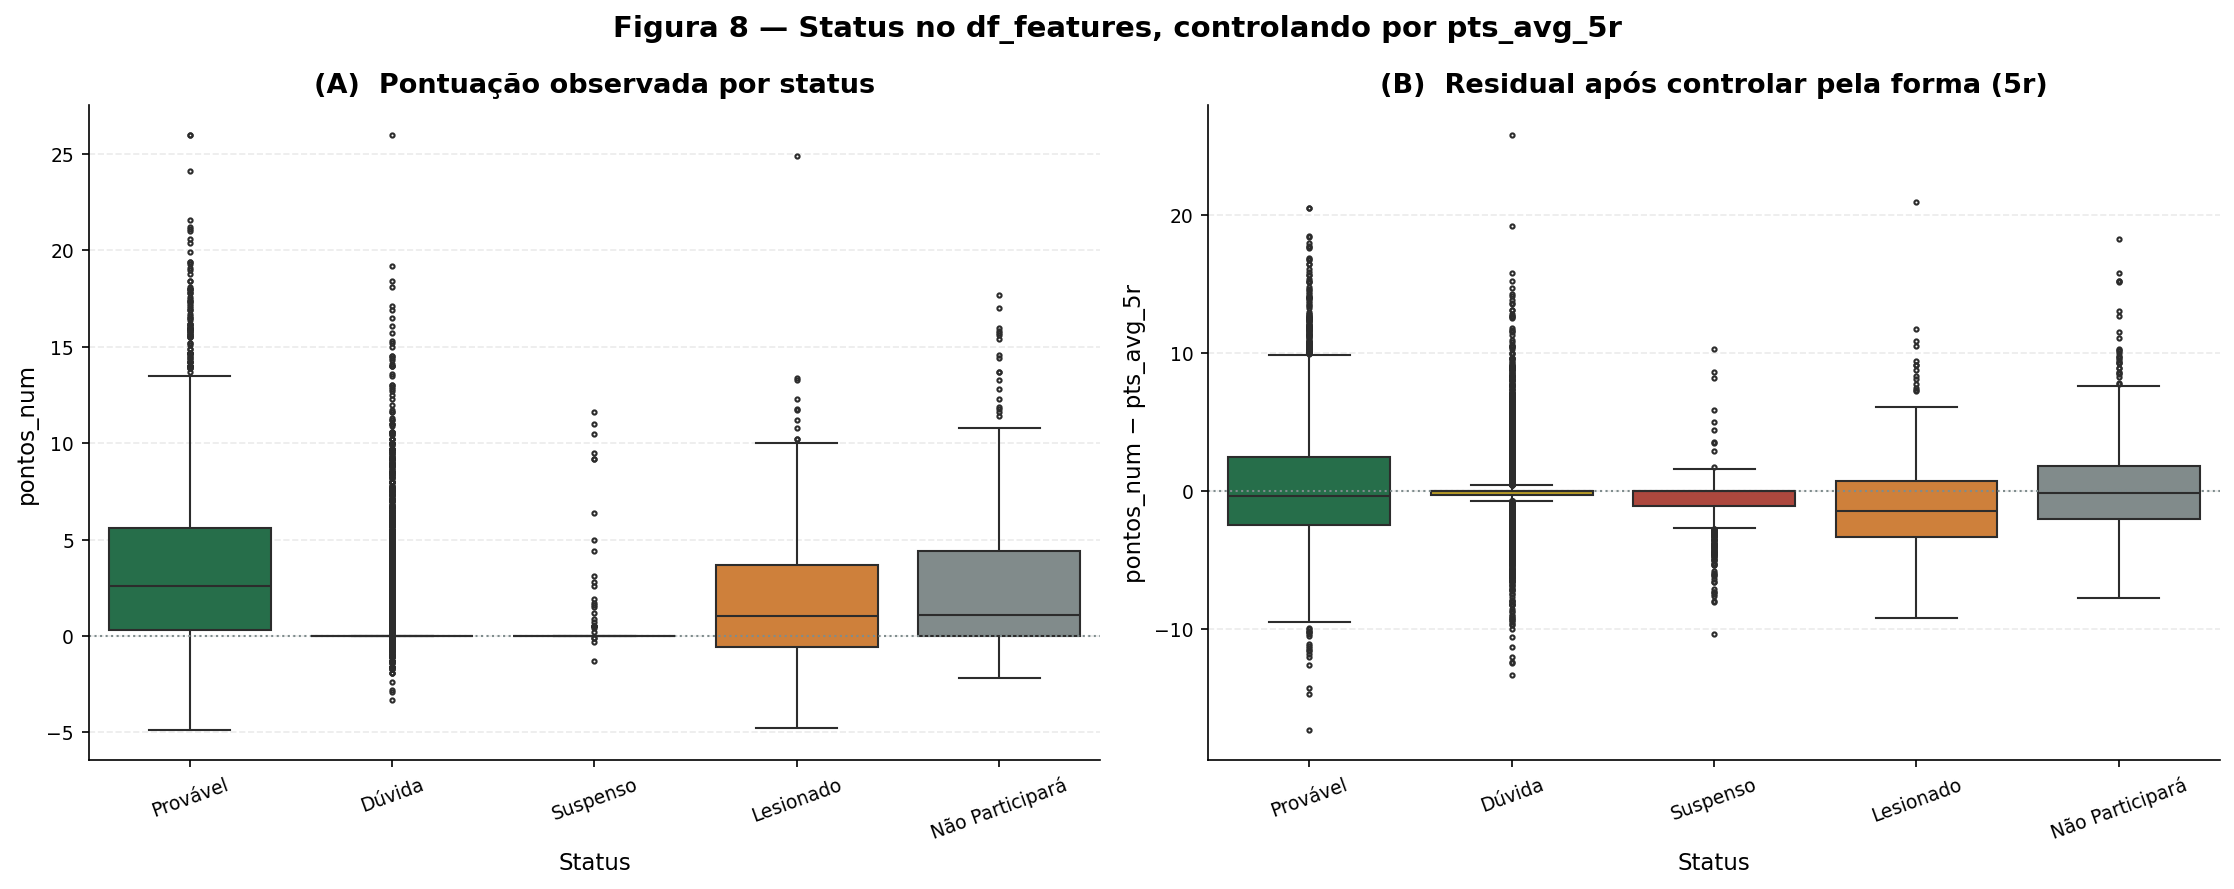

In [9]:
df_status = df.dropna(subset=["pts_avg_5r", "pontos_num", "status_id"]).copy()
df_status["residual"] = df_status["pontos_num"] - df_status["pts_avg_5r"]
df_status["is_provavel"] = (df_status["status_id"] == 7).astype(int)

status_table = (
    df_status.groupby("status_label")
    .agg(
        n=("pontos_num", "size"),
        mean_points=("pontos_num", "mean"),
        mean_pts_avg_5r=("pts_avg_5r", "mean"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
    )
    .reindex(STATUS_ORDER)
)
print("Status vs target, controlling for pts_avg_5r")
display(status_table.round(3))

groups = [
    df_status.loc[df_status["status_label"] == label, "residual"].to_numpy()
    for label in STATUS_ORDER
    if (df_status["status_label"] == label).any()
]
kruskal_stat, kruskal_p = stats.kruskal(*groups)
rho_prov, p_prov = stats.spearmanr(df_status["is_provavel"], df_status["residual"])
print(f"\nKruskal-Wallis on residual by status: H = {kruskal_stat:.3f}, p = {kruskal_p:.4g}")
print(f"Spearman(is_provavel, residual): ρ = {rho_prov:.4f}, p = {p_prov:.4g}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("white")

sns.boxplot(
    data=df_status,
    x="status_label",
    y="pontos_num",
    hue="status_label",
    order=STATUS_ORDER,
    palette=STATUS_COLORS,
    legend=False,
    fliersize=2,
    ax=axes[0],
)
axes[0].set_xlabel("Status")
axes[0].set_ylabel("pontos_num")
axes[0].set_title("(A)  Pontuação observada por status", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].axhline(0, color=CINZA, linestyle=":", linewidth=1)

sns.boxplot(
    data=df_status,
    x="status_label",
    y="residual",
    hue="status_label",
    order=STATUS_ORDER,
    palette=STATUS_COLORS,
    legend=False,
    fliersize=2,
    ax=axes[1],
)
axes[1].set_xlabel("Status")
axes[1].set_ylabel("pontos_num − pts_avg_5r")
axes[1].set_title("(B)  Residual após controlar pela forma (5r)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
axes[1].axhline(0, color=CINZA, linestyle=":", linewidth=1)

fig.suptitle("Figura 8 — Status no df_features, controlando por pts_avg_5r", fontweight="bold", fontsize=14)
fig.tight_layout()
save_fig(fig, "fig8_status_residual.png")


**Implicação metodológica.** O Kruskal–Wallis no residual rejeita igualdade entre status: suspensos e lesionados ficam abaixo da forma recente, enquanto Provável fica ligeiramente acima. A dummy binária Provável vs. resto no residual é fraca — a classe majoritária (Dúvida) já pontua perto da média histórica, então o sinal está nas **caudas de disponibilidade**. Isso valida `status_id` / `prob_jogar` como features, não só como filtro, com o caveat de que o canal é disponibilidade, não um efeito de skill residual.
